**AI Content Detection Using DistilBERT**

In [ ]:
import pandas as pd

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Training_Essay_Data.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution (generated):")
print(df["generated"].value_counts(dropna=False))

df.sample(3, random_state=42)

Shape: (29145, 2)
Columns: ['text', 'generated']

Label distribution (generated):
generated
0    17508
1    11637
Name: count, dtype: int64


,text,generated
17004,I would agree with Emerson's in this world be ...,0
14459,Advice is wonderful and helpful to everyone. S...,0
28492,I think that limiting car usage is great for t...,0


In [ ]:
from sklearn.model_selection import train_test_split
import re

In [ ]:
has_missing = df.isnull().values.any()
print(df.isnull().sum())

text         0
generated    0
dtype: int64


In [ ]:
print(df.columns)

Index(['text', 'generated'], dtype='object')


In [ ]:
df2 = df[["text", "generated"]].dropna().copy()
df2["text"] = df2["text"].astype(str)
df2["generated"] = df2["generated"].astype(int)

In [ ]:
def clean_text_minimal(s: str) -> str:
    s = s.replace("\r", " ").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

df2["text"] = df2["text"].apply(clean_text_minimal)

print("After cleaning:", df2.shape)
print("Label distribution:\n", df2["generated"].value_counts())

After cleaning: (29145, 2)
Label distribution:
 generated
0    17508
1    11637
Name: count, dtype: int64


In [ ]:
train_df, temp_df = train_test_split(
    df2,
    test_size=0.30,
    random_state=42,
    stratify=df2["generated"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["generated"]
)

print("\nSplit sizes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain label distribution:\n", train_df["generated"].value_counts(normalize=True))
print("\nVal label distribution:\n", val_df["generated"].value_counts(normalize=True))
print("\nTest label distribution:\n", test_df["generated"].value_counts(normalize=True))


Split sizes:
Train: (20401, 2)
Val  : (4372, 2)
Test : (4372, 2)

Train label distribution:
 generated
0    0.600706
1    0.399294
Name: proportion, dtype: float64

Val label distribution:
 generated
0    0.60064
1    0.39936
Name: proportion, dtype: float64

Test label distribution:
 generated
0    0.600869
1    0.399131
Name: proportion, dtype: float64


In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer

In [ ]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 512

In [ ]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LEN
    )
train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])

Map:   0%|          | 0/20401 [00:00<?, ? examples/s]

Map:   0%|          | 0/4372 [00:00<?, ? examples/s]

Map:   0%|          | 0/4372 [00:00<?, ? examples/s]

In [ ]:
train_tok = train_tok.rename_column("generated", "labels")
val_tok   = val_tok.rename_column("generated", "labels")
test_tok  = test_tok.rename_column("generated", "labels")

In [ ]:
cols = ["input_ids", "attention_mask", "labels"]
train_tok.set_format(type="torch", columns=cols)
val_tok.set_format(type="torch", columns=cols)
test_tok.set_format(type="torch", columns=cols)

print("Tokenized columns:", train_tok.column_names)
print("One sample keys:", train_tok[0].keys())
print("input_ids length:", len(train_tok[0]["input_ids"]))
print("labels example:", train_tok[0]["labels"])

Tokenized columns: ['labels', 'input_ids', 'attention_mask']
One sample keys: dict_keys(['labels', 'input_ids', 'attention_mask'])
input_ids length: 267
labels example: tensor(0)


In [ ]:
from transformers import AutoModelForSequenceClassification

In [ ]:
NUM_LABELS = 2

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_LABELS
)

model

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary"
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    fp16=True,
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

/tmp/ipython-input-1517645966.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.014300,0.026363,0.993596,0.985860,0.998282,0.992032
2,0.009300,0.027889,0.993596,0.985311,0.998855,0.992036
3,0.001400,0.022681,0.995883,0.991468,0.998282,0.994863


TrainOutput(global_step=1914, training_loss=0.019791755683867547, metrics={'train_runtime': 801.5873, 'train_samples_per_second': 76.352, 'train_steps_per_second': 2.388, 'total_flos': 8107402199943168.0, 'train_loss': 0.019791755683867547, 'epoch': 3.0})

In [ ]:
test_results = trainer.evaluate(test_tok)
print("Test Results:", test_results)

Test Results: {'eval_loss': 0.03439963236451149, 'eval_accuracy': 0.9929094236047575, 'eval_precision': 0.9847285067873304, 'eval_recall': 0.9977077363896848, 'eval_f1': 0.991175633361799, 'eval_runtime': 16.4265, 'eval_samples_per_second': 266.155, 'eval_steps_per_second': 8.34, 'epoch': 3.0}


In [ ]:
pred_output = trainer.predict(test_tok)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=1)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

y_true shape: (4372,)
y_pred shape: (4372,)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

target_names = ["Human (0)", "AI (1)"]

print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

              precision    recall  f1-score   support

   Human (0)     0.9985    0.9897    0.9941      2627
      AI (1)     0.9847    0.9977    0.9912      1745

    accuracy                         0.9929      4372
   macro avg     0.9916    0.9937    0.9926      4372
weighted avg     0.9930    0.9929    0.9929      4372

Confusion Matrix:
 [[2600   27]
 [   4 1741]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

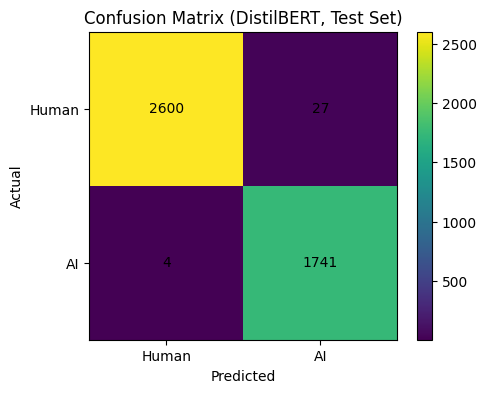

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix (DistilBERT, Test Set)")
plt.xticks([0, 1], ["Human", "AI"])
plt.yticks([0, 1], ["Human", "AI"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.show()

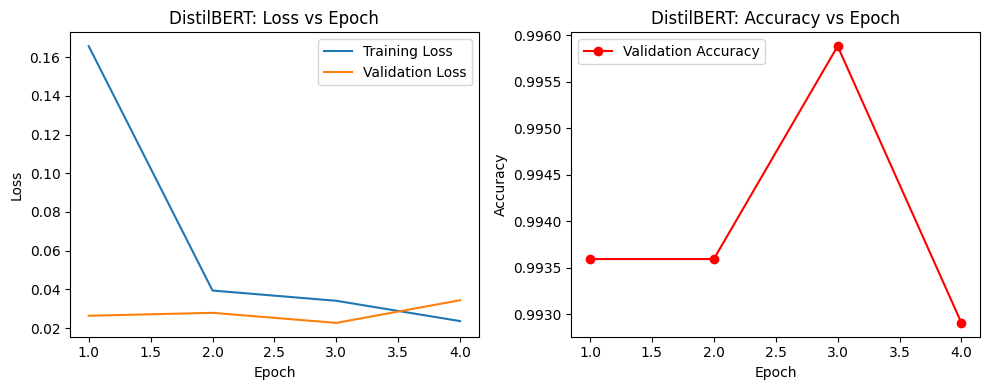

In [ ]:
log_history = trainer.state.log_history

train_loss = [entry["loss"] for entry in log_history if "loss" in entry]
eval_loss  = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]
eval_acc   = [entry["eval_accuracy"] for entry in log_history if "eval_accuracy" in entry]

epochs = list(range(1, len(eval_loss) + 1))

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss[:len(epochs)], label="Training Loss")
plt.plot(epochs, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT: Loss vs Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, eval_acc, marker="o", color="red", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DistilBERT: Accuracy vs Epoch")
plt.legend()

plt.tight_layout()
plt.show()